# Results Analysis
This notebook summarizes model performance artifacts, compares available runs, and highlights qualitative prediction behavior.

## Setup
Load common dependencies and define helper paths for result discovery.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path('..')
RESULTS_DIR = ROOT / 'results'
print('Results directory:', RESULTS_DIR.resolve())

Results directory: C:\Users\karth\ML4SCIPROTO2\faseroH-prototype\results


## Training Curves
Plot train/validation loss from the latest available history file.

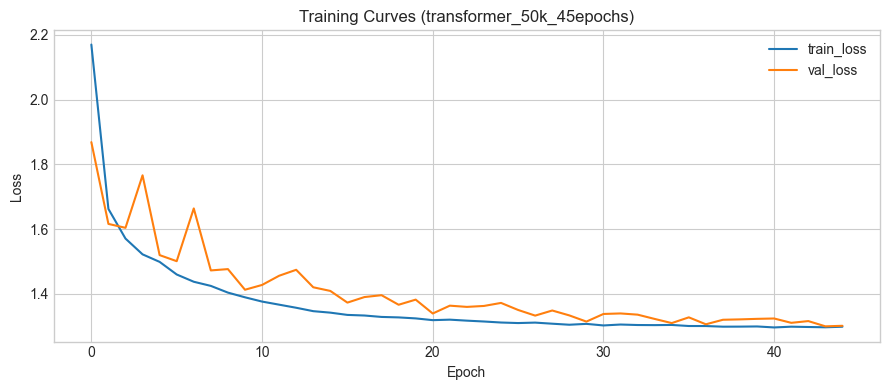

WindowsPath('../results/transformer_50k_45epochs/training_logs/history.json')

In [2]:
history_candidates = sorted(RESULTS_DIR.glob('**/training_logs/history.json'))
if not history_candidates:
    raise FileNotFoundError('No training history found under results/**/training_logs/history.json')

history_path = history_candidates[-1]
history = json.loads(history_path.read_text(encoding='utf-8'))
hist_df = pd.DataFrame(history)

ax = hist_df[['train_loss', 'val_loss']].plot(figsize=(9, 4))
ax.set_title(f'Training Curves ({history_path.parent.parent.name})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

history_path

## Full Evaluation Metrics
Load `metrics_full.json` (when present) and print a clean formatted summary.

In [3]:
metrics_paths = sorted(RESULTS_DIR.glob('**/metrics_full.json'))
if not metrics_paths:
    raise FileNotFoundError('No metrics_full.json found under results/**')

selected_metrics_path = metrics_paths[-1]
payload = json.loads(selected_metrics_path.read_text(encoding='utf-8'))
print('Using:', selected_metrics_path)
print(json.dumps(payload, indent=2))

fit_df = pd.DataFrame([payload.get('fit', {})])
test_df = pd.DataFrame([payload.get('test', {})])
display(fit_df)
display(test_df)

Using: ..\results\transformer_50k_45epochs\metrics_full.json
{
  "fit": {
    "best_val_loss": 1.299525991366927,
    "best_epoch": 43
  },
  "test": {
    "token_accuracy": 0.42356591165495094,
    "sequence_accuracy": 0.0446,
    "bleu": 0.15786992536046732,
    "edit_distance": 5.3838,
    "semantic_equivalence": 0.0468,
    "coefficient_mse": 60189.70130973779
  }
}


,best_val_loss,best_epoch
0,1.299526,43


,token_accuracy,sequence_accuracy,bleu,edit_distance,semantic_equivalence,coefficient_mse
0,0.423566,0.0446,0.15787,5.3838,0.0468,60189.70131


## LSTM vs Transformer Comparison
If both model metrics exist, build a side-by-side table for quick comparison.

In [4]:
rows = []
for p in metrics_paths:
    run_name = p.parent.name.lower()
    model = None
    if 'lstm' in run_name:
        model = 'lstm'
    if 'transformer' in run_name:
        model = 'transformer'
    if model is None:
        continue
    m = json.loads(p.read_text(encoding='utf-8')).get('test', {})
    rows.append({'run': p.parent.name, 'model': model, **m})

cmp_df = pd.DataFrame(rows)
if cmp_df.empty:
    print('No LSTM/Transformer metrics_full.json pair found yet.')
else:
    display(cmp_df.sort_values(['model', 'run']).reset_index(drop=True))

,run,model,token_accuracy,sequence_accuracy,bleu,edit_distance,semantic_equivalence,coefficient_mse
0,transformer_50k_45epochs,transformer,0.423566,0.0446,0.15787,5.3838,0.0468,60189.70131


## Correct vs Incorrect Predictions
Separate exact matches and mismatches from available prediction artifacts.

In [5]:
pred_candidates = sorted(RESULTS_DIR.glob('**/predictions.json'))
if not pred_candidates:
    print('No predictions.json found. Run an evaluation pipeline that exports predictions.')
else:
    pred_path = pred_candidates[-1]
    pred_payload = json.loads(pred_path.read_text(encoding='utf-8'))
    pred_df = pd.DataFrame({
        'prediction': pred_payload.get('predictions', []),
        'target': pred_payload.get('targets', []),
        'input': pred_payload.get('inputs', []),
    })
    pred_df['exact_match'] = pred_df['prediction'].astype(str).str.strip() == pred_df['target'].astype(str).str.strip()
    print('Predictions file:', pred_path)
    print('Exact match counts:')
    print(pred_df['exact_match'].value_counts())
    correct_df = pred_df[pred_df['exact_match']].reset_index(drop=True)
    incorrect_df = pred_df[~pred_df['exact_match']].reset_index(drop=True)
    display(correct_df.head(5))
    display(incorrect_df.head(5))

Predictions file: ..\results\transformer\predictions.json
Exact match counts:
exact_match
False    1897
True      103
Name: count, dtype: int64


,prediction,target,input,exact_match
0,x**3,x**3,x**3,True
1,-x - 4,-x - 4,-x - 4,True
2,-x**4,-x**4,-x**4,True
3,5*x - 3,5*x - 3,5*x - 3,True
4,6*x**4,6*x**4,6*x**4,True


,prediction,target,input,exact_match
0,x**4*(-191*cos(1) + 96*sin(1))/24 - x**3*(sin(...,1,cos(x**4),False
1,-299*x**4*cos(5)/24 + x**3*sin(5)/6 - x**2*cos...,x**4*cos(5)/24 - x**3*sin(5)/6 - x**2*cos(5)/2...,cos(x - 5),False
2,x**4/24 + x**3/6 + 3*x**2/2 + 2*x + 2,E*x**4/24 + E*x**3/6 + E*x**2/2 + E*x + E,exp(x + 1),False
3,x**4*cos(4)/24 + x**3*sin(4)/6 - x**2*cos(4)/2...,x**4*cos(4)/24 - x**3*sin(4)/6 - x**2*cos(4)/2...,cos(x - 4),False
4,-191*x**4*sin(4)/24 + x**3*cos(4)/6 - x**2*sin...,x**4*sin(4)/24 - x**3*cos(4)/6 - x**2*sin(4)/2...,sin(x + 4),False


## Qualitative Examples
Show representative examples for quick presentation and error inspection.

In [6]:
sample_candidates = sorted(RESULTS_DIR.glob('**/sample_predictions.json'))
if sample_candidates:
    sample_path = sample_candidates[-1]
    sample_payload = json.loads(sample_path.read_text(encoding='utf-8'))
    sample_df = pd.DataFrame(sample_payload)
    print('Sample predictions:', sample_path)
    display(sample_df.head(10))
else:
    print('No sample_predictions.json found yet.')

Sample predictions: ..\results\transformer\sample_predictions.json


,input_function,target_taylor,predicted_taylor,semantic_equivalent
0,x**3,x**3,x**3,True
1,cos(x**4),1,x**4*(-191*cos(1) + 96*sin(1))/24 - x**3*(sin(...,False
2,-x - 4,-x - 4,-x - 4,True
3,cos(x - 5),x**4*cos(5)/24 - x**3*sin(5)/6 - x**2*cos(5)/2...,-299*x**4*cos(5)/24 + x**3*sin(5)/6 - x**2*cos...,False
4,exp(x + 1),E*x**4/24 + E*x**3/6 + E*x**2/2 + E*x + E,x**4/24 + x**3/6 + 3*x**2/2 + 2*x + 2,False
5,cos(x - 4),x**4*cos(4)/24 - x**3*sin(4)/6 - x**2*cos(4)/2...,x**4*cos(4)/24 + x**3*sin(4)/6 - x**2*cos(4)/2...,False
6,sin(x + 4),x**4*sin(4)/24 - x**3*cos(4)/6 - x**2*sin(4)/2...,-191*x**4*sin(4)/24 + x**3*cos(4)/6 - x**2*sin...,False
7,exp(x - 3),x**4*exp(-3)/24 + x**3*exp(-3)/6 + x**2*exp(-3...,(x**4/24 + x**3/6 + x**2/2 - x + 1)*exp(-3),False
8,sin(4*x),-32*x**3/3 + 4*x,-8*x**3 + 4*x,False
9,-x**4,-x**4,-x**4,True
